# ECON4002 — Week 3: Calculus & Functions in R

**University of Western Australia**  
*Numerical differentiation, elasticity, Cobb-Douglas, and growth rates*

---

## Key Formulae

Numerical derivative: $f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$. Cobb-Douglas: $Q = AL^{\alpha}K^{\beta}$

---

> **How to use:** Run each cell in order. Modify the parameters and re-run to explore the economics.

In [ ]:
# ECON4002 Week 3 — R Setup
# Run this cell first to configure options
options(scipen = 6, digits = 4)
cat('Week 3: Calculus & Functions in R — ready!\n')

Week 3: Calculus & Functions in R — ready!


## Differentiation

### W3-CS01 — Numerical Derivative

> **Note:** Central difference formula is more accurate than forward difference.

In [ ]:
numerical_derivative <- function(f, x, h = 1e-6) {
  (f(x + h) - f(x - h)) / (2 * h)
}

# Test: f(x) = x³, f'(x) = 3x²
f <- function(x) x^3
numerical_derivative(f, x = 2)  # 12

### W3-CS02 — Partial Derivatives

> **Note:** Hold other variables constant when taking partial derivative.

In [ ]:
partial_x <- function(f, x, y, h = 1e-6) {
  (f(x + h, y) - f(x - h, y)) / (2 * h)
}

partial_y <- function(f, x, y, h = 1e-6) {
  (f(x, y + h) - f(x, y - h)) / (2 * h)
}

# f(x,y) = 3x² + 2xy
f <- function(x, y) 3*x^2 + 2*x*y
partial_x(f, 1, 2)  # 6(1) + 2(2) = 10

### W3-CS03 — Gradient Vector

> **Note:** Gradient is vector of all partial derivatives. Zero gradient → critical point.

In [ ]:
gradient <- function(f, x, h = 1e-6) {
  n <- length(x)
  grad <- numeric(n)
  for (i in 1:n) {
    x_plus <- x_minus <- x
    x_plus[i] <- x[i] + h
    x_minus[i] <- x[i] - h
    grad[i] <- (f(x_plus) - f(x_minus)) / (2 * h)
  }
  return(grad)
}

f <- function(x) x[1]^2 + 3*x[1]*x[2]
gradient(f, c(1, 2))  # [2+6, 3] = [8, 3]

## Elasticity

### W3-CS04 — Point Elasticity

> **Note:** ε = (dQ/dP)·(P/Q). Negative for demand. |ε|>1 is elastic.

In [ ]:
elasticity <- function(demand_fn, P, h = 1e-6) {
  Q <- demand_fn(P)
  dQ_dP <- (demand_fn(P + h) - demand_fn(P - h)) / (2 * h)
  return(dQ_dP * P / Q)
}

demand <- function(P) 200 - 4*P
elasticity(demand, 25)  # -1.0 (unit elastic)

### W3-CS05 — Constant Elasticity Demand

> **Note:** Log-log specification: ln Q = ln a + b·ln P → elasticity = b (constant).

In [ ]:
# Q = a·P^b has constant elasticity = b
demand_ce <- function(P) 100 * P^(-0.8)

# Verify at multiple prices
for (P in c(5, 10, 20)) {
  e <- elasticity(demand_ce, P)
  cat('P =', P, ': ε =', round(e, 3), '\n')
}
# All give -0.8

## Cost

### W3-CS06 — Cost Functions

> **Note:** MC = dTC/dQ. AC minimized where MC = AC.

In [ ]:
total_cost <- function(Q, F = 100, a = 20, b = 0.5) {
  F + a*Q + b*Q^2
}

marginal_cost <- function(Q, a = 20, b = 0.5) {
  a + 2*b*Q
}

average_cost <- function(Q, F = 100, a = 20, b = 0.5) {
  total_cost(Q, F, a, b) / Q
}

# MC intersects AC at minimum AC
Q_min_AC <- sqrt(F / b)  # √(100/0.5) = 14.14

## Revenue

### W3-CS07 — Revenue and Marginal Revenue

> **Note:** MR = dTR/dQ. For linear demand P = a - bQ, MR = a - 2bQ.

In [ ]:
# P = 100 - 2Q (inverse demand)
total_revenue <- function(Q) Q * (100 - 2*Q)
marginal_revenue <- function(Q) 100 - 4*Q

# Revenue max where MR = 0
Q_max_rev <- 100 / 4  # 25

plot(0:50, total_revenue(0:50), type = 'l')
abline(v = Q_max_rev, lty = 2)

## Production

### W3-CS08 — Cobb-Douglas Production

> **Note:** MP_L = α·Q/L (constant share of APL). Output elasticity = α.

In [ ]:
cobb_douglas <- function(L, K, A = 10, alpha = 0.3, beta = 0.7) {
  A * L^alpha * K^beta
}

MP_L <- function(L, K, A = 10, alpha = 0.3, beta = 0.7) {
  alpha * cobb_douglas(L, K, A, alpha, beta) / L
}

MP_K <- function(L, K, A = 10, alpha = 0.3, beta = 0.7) {
  beta * cobb_douglas(L, K, A, alpha, beta) / K
}

# Test
cobb_douglas(100, 50)  # Output
MP_L(100, 50)          # Marginal product of L

### W3-CS09 — MRTS

> **Note:** MRTS is slope of isoquant. Diminishes as L/K rises (convex isoquants).

In [ ]:
# MRTS = -MP_L/MP_K = -(α/β)·(K/L)
MRTS <- function(L, K, alpha = 0.3, beta = 0.7) {
  -(alpha/beta) * (K/L)
}

# At L=100, K=50
MRTS(100, 50)  # -(0.3/0.7)·(50/100) = -0.214

# Interpretation: Can give up 0.214 K per extra L

### W3-CS10 — Returns to Scale

> **Note:** For CD: Q(tL,tK) = t^(α+β)·Q. α+β=1→CRS, >1→IRS, <1→DRS.

In [ ]:
# Scale all inputs by t, check output scaling
test_RTS <- function(t, L = 100, K = 50, alpha = 0.3, beta = 0.7) {
  Q1 <- cobb_douglas(L, K, alpha = alpha, beta = beta)
  Q2 <- cobb_douglas(t*L, t*K, alpha = alpha, beta = beta)
  return(Q2 / Q1)
}

t <- 2
ratio <- test_RTS(t)
cat('If t =', t, ', output scales by', ratio, '\n')
cat('RTS:', ifelse(ratio == t, 'CRS', 
                   ifelse(ratio > t, 'IRS', 'DRS')))

### W3-CS11 — Isoquant Plotting

> **Note:** Isoquant shows all (L,K) combinations producing same Q.

In [ ]:
# For Q = A·L^α·K^β, K = (Q/(A·L^α))^(1/β)
isoquant <- function(L, Q_target, A = 10, alpha = 0.3, beta = 0.7) {
  (Q_target / (A * L^alpha))^(1/beta)
}

L_range <- 10:200
plot(L_range, isoquant(L_range, 100), type = 'l',
     xlab = 'L', ylab = 'K', main = 'Isoquant Q = 100')

## Growth

### W3-CS12 — Continuous Growth

> **Note:** Growth rate g = d(ln Y)/dt. Rule of 70: doubling time ≈ 70/g%.

In [ ]:
# Y(t) = Y₀·e^(gt)
continuous_growth <- function(Y0, g, t) Y0 * exp(g * t)

# 3% growth for 20 years
Y <- continuous_growth(100, 0.03, 0:20)
plot(0:20, Y, type = 'l', main = 'Growth at 3%')

# Doubling time
T_double <- log(2) / 0.03  # 23.1 years

### W3-CS13 — Log Difference as Growth Rate

> **Note:** Log differences additive: ln(Y2/Y1) = ln Y2 - ln Y1.

In [ ]:
# For small changes: % change ≈ Δ ln(Y)
Y <- c(100, 103, 106.09)

# Standard growth rate
growth_std <- diff(Y) / head(Y, -1)

# Log difference
growth_log <- diff(log(Y))

cbind(Standard = growth_std, Log = growth_log)
# Nearly identical for small changes

## Symbolic

### W3-CS14 — Symbolic Differentiation

> **Note:** D() returns expression. For functions, use Deriv package.

In [ ]:
# R's built-in D() for symbolic derivatives
expr <- expression(3*x^2 + 2*x + 5)
D(expr, 'x')  # Returns: 3 * (2 * x) + 2

# Product rule automatically applied
expr2 <- expression(x^2 * exp(x))
D(expr2, 'x')

## Viewer Test: HTML Table Output

The cell below has a pre-rendered HTML table (simulating a data frame `print()`). This tests the notebook viewer's HTML output rendering.

In [ ]:
# Data frame display — output pre-rendered for viewer testing
farm_data <- data.frame(
  crop    = c('wheat', 'corn', 'soybean'),
  yield   = c(45, 180, 50),
  price   = c(7.50, 4.50, 13.00),
  revenue = c(337.50, 810.00, 650.00)
)
farm_data

,crop,yield,price,revenue
0,wheat,45,7.50,337.50
1,corn,180,4.50,810.00
2,soybean,50,13.00,650.00


## Viewer Test: Image Output

The cell below has a pre-rendered supply & demand plot. This tests the notebook viewer's image rendering.

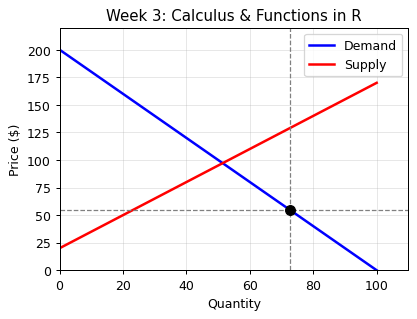

In [ ]:
# Supply & demand plot — output pre-rendered for viewer testing
P_range <- seq(0, 100, by = 0.5)
Qd <- 200 - 2 * P_range
Qs <- 20 + 1.5 * P_range
plot(Qd, P_range, type='l', col='blue', lwd=2,
     xlab='Quantity', ylab='Price', main='Supply & Demand')
lines(Qs, P_range, col='red', lwd=2)
legend('topright', c('Demand','Supply'), col=c('blue','red'), lty=1)

## Viewer Test: Empty Cell

The cell below is intentionally empty — the viewer should skip it gracefully.

## Common Patterns

**Elasticity at Point**

```r
elasticity <- function(f, x) {
  h <- 1e-6
  df_dx <- (f(x+h) - f(x-h)) / (2*h)
  df_dx * x / f(x)
}
```

**Marginal Product**

```r
MP_L <- function(L, K) {
  alpha * production(L, K) / L
}
```

**Profit Maximization**

```r
profit <- function(Q) TR(Q) - TC(Q)
result <- optimize(profit, c(0, 100), maximum = TRUE)
Q_star <- result$maximum
```

## Debugging Tips

| Error | Cause | Fix |
|-------|-------|-----|
| `NaN or Inf in derivative` | Function undefined at point (e.g., log(0), 1/0) | Check domain; use pmax to ensure positive values |
| `Wrong elasticity sign` | Forgot that demand elasticity is negative | Price elasticity of demand should be ≤ 0 |
| `Output elasticity not constant` | Not using true Cobb-Douglas form | For CD, output elasticity = exponent (always) |